# Visualizing MNIST with Tree-SNE

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

from tree_sne import TreeSNE
from data_generation import get_mnist

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style('ticks')

from scipy.interpolate import splprep, splev
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
X, y = get_mnist()

X.shape

(70000, 784)


In [ ]:
treeSNE = TreeSNE(X, 2, 0.01, 50)
treeSNE.fit()
fits = treeSNE.fits

In [3]:
fits = np.load('mnist-data/mnist-fits.npy')

In [5]:
stack_fits = np.zeros((51, X.shape[0], 3))
for i in range(51):
    stack_fits[i] = np.column_stack((fits[i], i * np.ones(X.shape[0])))

In [6]:
col = np.array(['#C51981','#ED1C24','#EC8D22','#F2E505','#C4D92F',
                '#7AC360','#62C6C0','#10769A','#664A93','#9753A1', '#ffff99'])

In [7]:
stack_x = stack_fits[:, :, 0].T
stack_y = stack_fits[:,:,1].T
stack_z = stack_fits[:,:,2].T

100%|██████████| 70000/70000 [02:14<00:00, 520.60it/s]


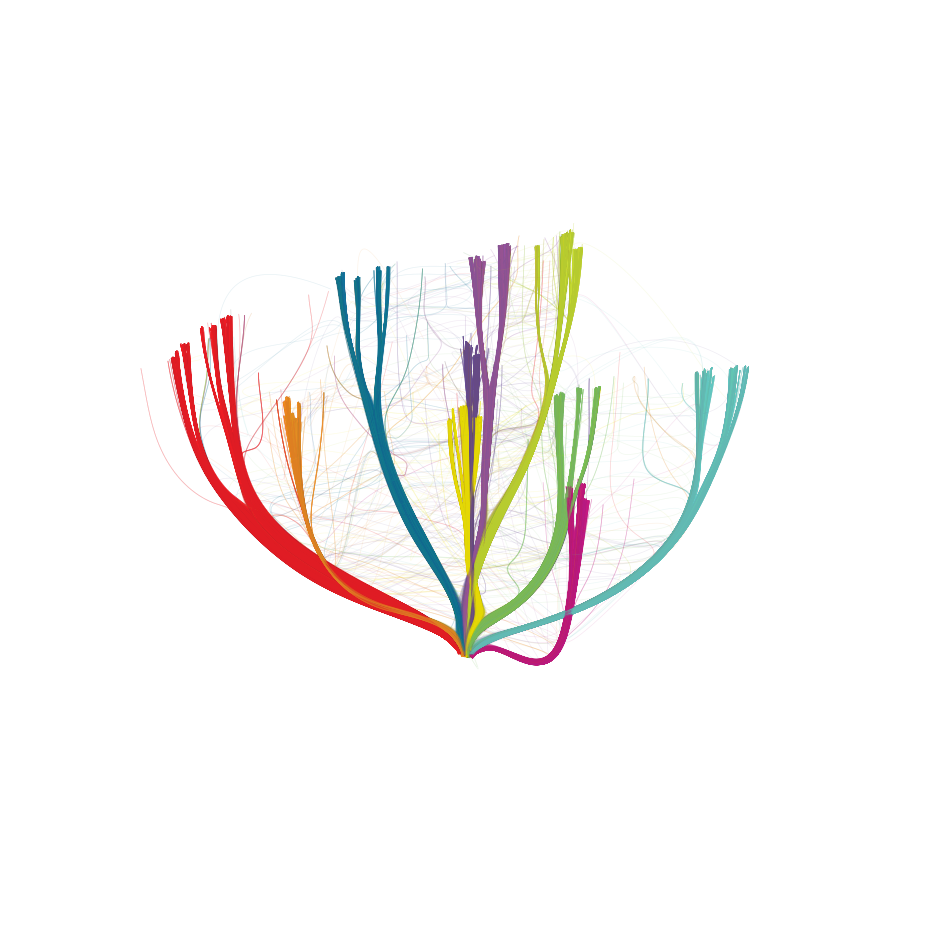

<Figure size 640x480 with 0 Axes>

In [ ]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')
    
for i in range(stack_fits.shape[1]):

# Fit a parametric spline to (x, y) over time
    points = [stack_x[i], stack_y[i], stack_z[i]]  # parametric curve in 3D

    tck, u = splprep(points, s=0.5)  # s is smoothing factor

    # Evaluate spline at finer resolution
    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth, t_smooth = splev(u_fine, tck)


    ax.plot(x_smooth, y_smooth, t_smooth, alpha=0.1, color=col[y[i]], linewidth=0.5)

ax.axis('off')
#ax.legend()
plt.show()

plt.savefig('figures/mnist-3d-tree-smooth.png')

In [4]:
y=np.array(y)

In [5]:
r = np.exp(np.log(0.01)/50)

In [5]:
plt.rcParams['text.usetex'] = True

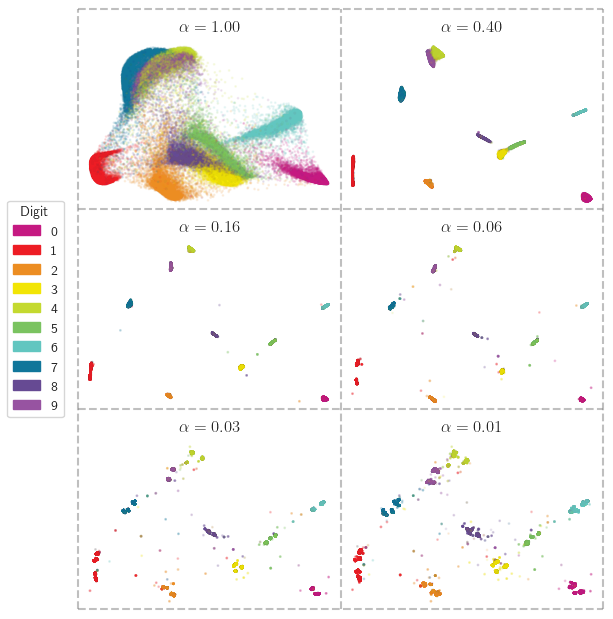

In [98]:
fig = plt.figure(figsize=(6, 6))

t_margin = 0
b_margin = 0
r_margin = 0
l_margin = 0.125

m = 0.05

ncols, nrows = 2, 3
w, h = (1.0-r_margin-l_margin) / ncols, (1.0-t_margin - b_margin) / nrows -m  # width and height of each subplot

for i in range(6):
    fit = fits[i*10]

    col_idx = i % ncols
    row_idx = i // ncols

    left = col_idx * w + l_margin
    bottom = (1-t_margin) - (row_idx+1) * (h + m)
    ax = fig.add_axes([left, bottom, w, h])

    ax.scatter(fit[:, 0], fit[:, 1], c=[col[val] for val in y], s=1, alpha=0.1)
    ax.set_title(r'$\alpha = %.2f$' % (r**(i*10)))
    ax.axis('off')

handles = [mpatches.Patch(color=col[val], label=str(val)) for val in np.unique(y)]

fig.add_artist(plt.Line2D([l_margin, 1-r_margin], [(1-t_margin+b_margin)/3, (1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([l_margin, 1-r_margin], [2*(1-t_margin+b_margin)/3, 2*(1-t_margin+b_margin)/3], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([l_margin, 1-r_margin], [(b_margin), (b_margin)], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([l_margin, 1-r_margin], [1,1], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([l_margin, l_margin], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([1-r_margin, 1-r_margin], [b_margin,1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
fig.add_artist(plt.Line2D([(1-r_margin+l_margin)/2, (1-r_margin+l_margin)/2], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))
#fig.add_artist(plt.Line2D([2*(1-r_margin)/3, 2*(1-r_margin)/3], [b_margin, 1-t_margin], linestyle='dashed', alpha=0.5, color='gray'))

fig.legend(handles=handles, loc="center left", handlelength=2, title='Digit', ncols=1, frameon='False')

#plt.savefig('mnist-slices.png')


## DBSCAN at different levels

In [16]:
from sklearn.cluster import DBSCAN

In [ ]:
labellings = []

for i in range(6):
    clustering = DBSCAN().fit(fits[i*10])
    labellings.append(clustering.labels_)

np.save('mnist-labellings.npy', labellings)

In [10]:
labellings = np.load('mnist-data/mnist-labellings.npy')

labels = []
counts = []

for i in range(6):
    labelling = labellings[i]
    l, c = np.unique(labelling, return_counts=True)
    labels.append(l)
    counts.append(c)


Finding average elements of each cluster.

In [100]:
X.shape

(70000, 784)

In [101]:
len(np.where(labellings[3]==-1)[0])

66

In [28]:
Xnp = X.to_numpy()

In [29]:
avg_im = []
avg_label = []

for i in range(6):
    labelling = labellings[i]
    clusters = np.where(counts[i]>=50)[0]
    avgs = []
    ls = []
    for j in clusters:
        cluster = labels[i][j]
        if cluster != -1:
            inds = np.where(labelling == cluster)[0]

            ls.append(int(np.round(np.mean(np.array([y[inds[k]] for k in range(len(inds))])), decimals=0)))
            
            avgs.append(np.mean(np.array([Xnp[inds[k]] for k in range(len(inds))]), axis=0).reshape((28, 28)))
        
    avg_im.append(avgs)
    avg_label.append(ls)


(-0.5, 27.5, 27.5, -0.5)

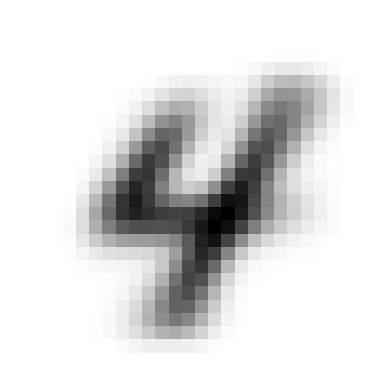

In [55]:
plt.imshow(avg_im[5][8], cmap='gray_r')
plt.axis('off')

In [106]:
len(avg_im[0])

1

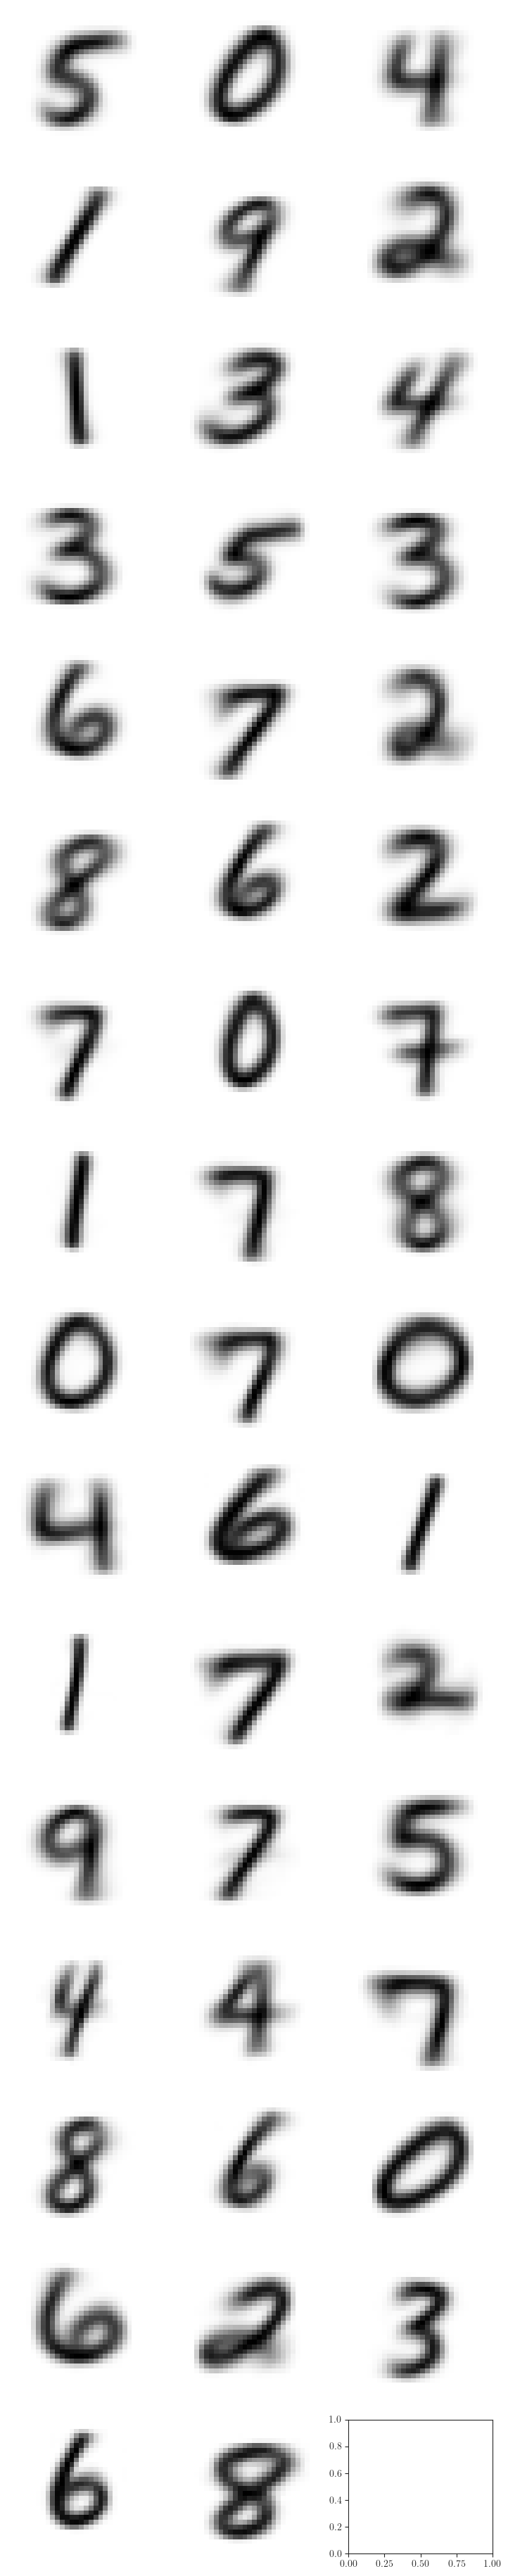

In [107]:
avgs = avg_im[5]

fig, axs = plt.subplots(nrows=int(np.ceil(len(avgs)/3)), ncols=3, figsize=(9,len(avgs)))

for i in range(len(avgs)):
    axs[i//3, i%3].imshow(avgs[i], cmap='gray_r')
    axs[i//3, i%3].axis('off')

In [30]:
np.where(labellings[5]==37)[0].shape

(102,)

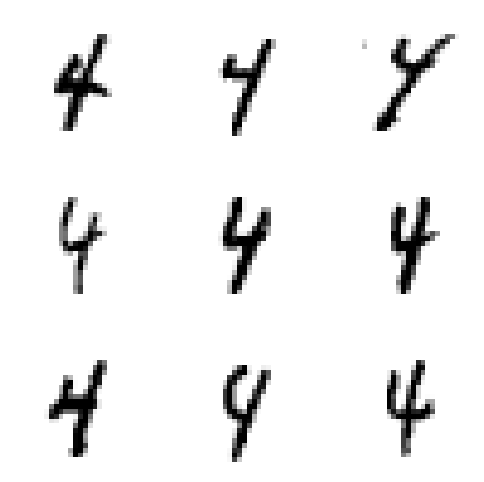

In [124]:
fig, axs = plt.subplots(nrows = 3, ncols=3, figsize= (6, 6))

clusters = [5, 17, 13, 20]

for i in range(9):
    row_idx = (i//3)%3
    col_idx = i%3
    axs[row_idx, col_idx].imshow(Xnp[np.where(labellings[5] == 37)[0]][i+16].reshape((28, 28)), cmap='gray_r')
    axs[row_idx, col_idx].axis('off')

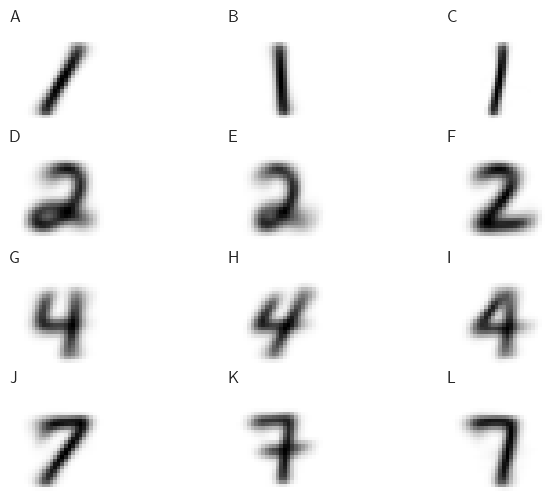

In [11]:
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(8,6))
digits = [1, 2, 4, 7]
cl = {1: [3, 6, 30],
      2: [5, 14, 17],
     4: [2, 8, 37],
     7: [13, 20, 22]}

for i in range(len(digits)):
    d = digits[i]
    for j in range(3):
        axs[i, j].imshow(avgs[cl[d][j]], cmap='gray_r')
        axs[i, j].axis('off')
        axs[i, j].set_title(chr(97+i*3+j).upper(), loc='left')



In [114]:
from adjustText import adjust_text

([Text(-41.117773923297506, -19.412401966020383, 'A'),
  Text(-41.94824084437843, -11.645701675362268, 'B'),
  Text(-26.320273947966342, -17.810229203829998, 'C'),
  Text(-10.640784295761826, -29.950708665059842, 'D'),
  Text(-14.317511136372119, -25.585543714956945, 'E'),
  Text(-18.040733002230596, -27.508486829760695, 'F'),
  Text(-7.61170251974238, 36.44918496027808, 'G'),
  Text(-0.5378020628793152, 39.57509858306111, 'H'),
  Text(-3.394168392727849, 35.03921016062849, 'I'),
  Text(-32.70869528588511, 7.9550523301785745, 'J'),
  Text(-24.579858959689936, 13.992018870389863, 'K'),
  Text(-27.5348408709375, 17.749937361246047, 'L')],
  <matplotlib.patches.FancyArrowPatch at 0x127bc0a90>])

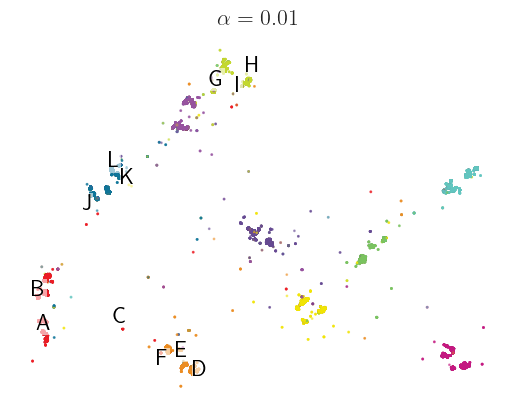

In [137]:
plt.scatter(fits[50][:, 0], fits[50][:, 1], c=col[y], s=1, alpha=0.5)
plt.axis('off')
plt.title(r'$\alpha = %.2f$' % 0.01, fontsize=16)

l = labellings[5]
centers = []

for d in digits:
    for i in range(3):
        cluster = fits[50][np.where(l == cl[d][i])]
        centers.append(np.mean(cluster, axis=0))

centers = np.array(centers)


texts = []
for i, (x, z) in enumerate(centers):
    texts.append(
        plt.text(
            x, z, chr(97+i).upper(),
            color='black',
            fontweight='bold',
            fontsize=16,
            ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1)
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

## How long does each layer of tree-SNE take?

In [12]:
times = np.load('mnist-data/times.npy')

In [19]:
labellings = np.load('mnist-data/mnist-labellings.npy')

In [ ]:
cluster_sizes = []

for i in tqdm(range(len(labellings))):
    l, c = np.unique(labellings[i], return_counts=True)
    if l[0] == -1:
        cluster_sizes.append(np.linalg.norm(c[1:])**2)
    else:
        cluster_sizes.append(np.linalg.norm(c)**2)

100%|██████████| 6/6 [00:00<00:00, 93.86it/s]


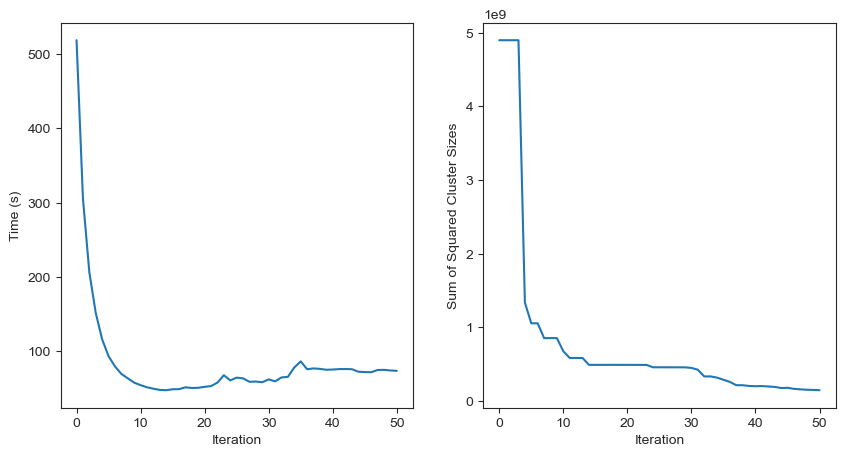

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))


axs[0].plot(range(51), times)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Time (s)')

axs[1].plot(range(51), cluster_sizes[::-1])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Sum of Squared Cluster Sizes')

plt.savefig('figures/time-vs-cluster-size.png')

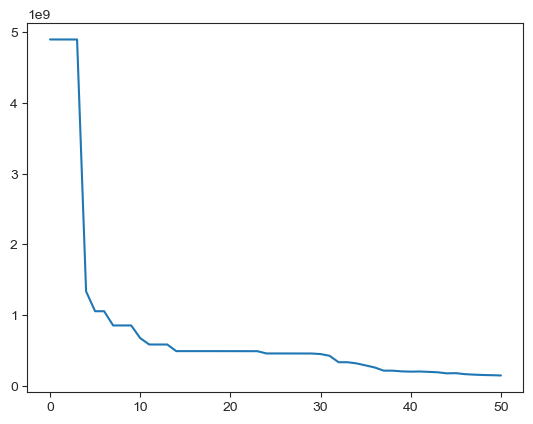

In [33]:
plt.plot(range(51), cluster_sizes[::-1])

In [ ]:
cluster_sizes = []

for i in range(51):
    clustering = DBSCAN().fit(fits[50-i])
    l, c = np.unique(clustering.labels_, return_counts=True)
    if l[0] == -1:
        cluster_sizes.append(np.linalg.norm(c[1:])**2)
    else:
        cluster_sizes.append(np.linalg.norm(c)**2)
    

100%|██████████| 51/51 [09:22<00:00, 11.03s/it]


## Some extra figures

100%|██████████| 70000/70000 [04:01<00:00, 289.70it/s] 


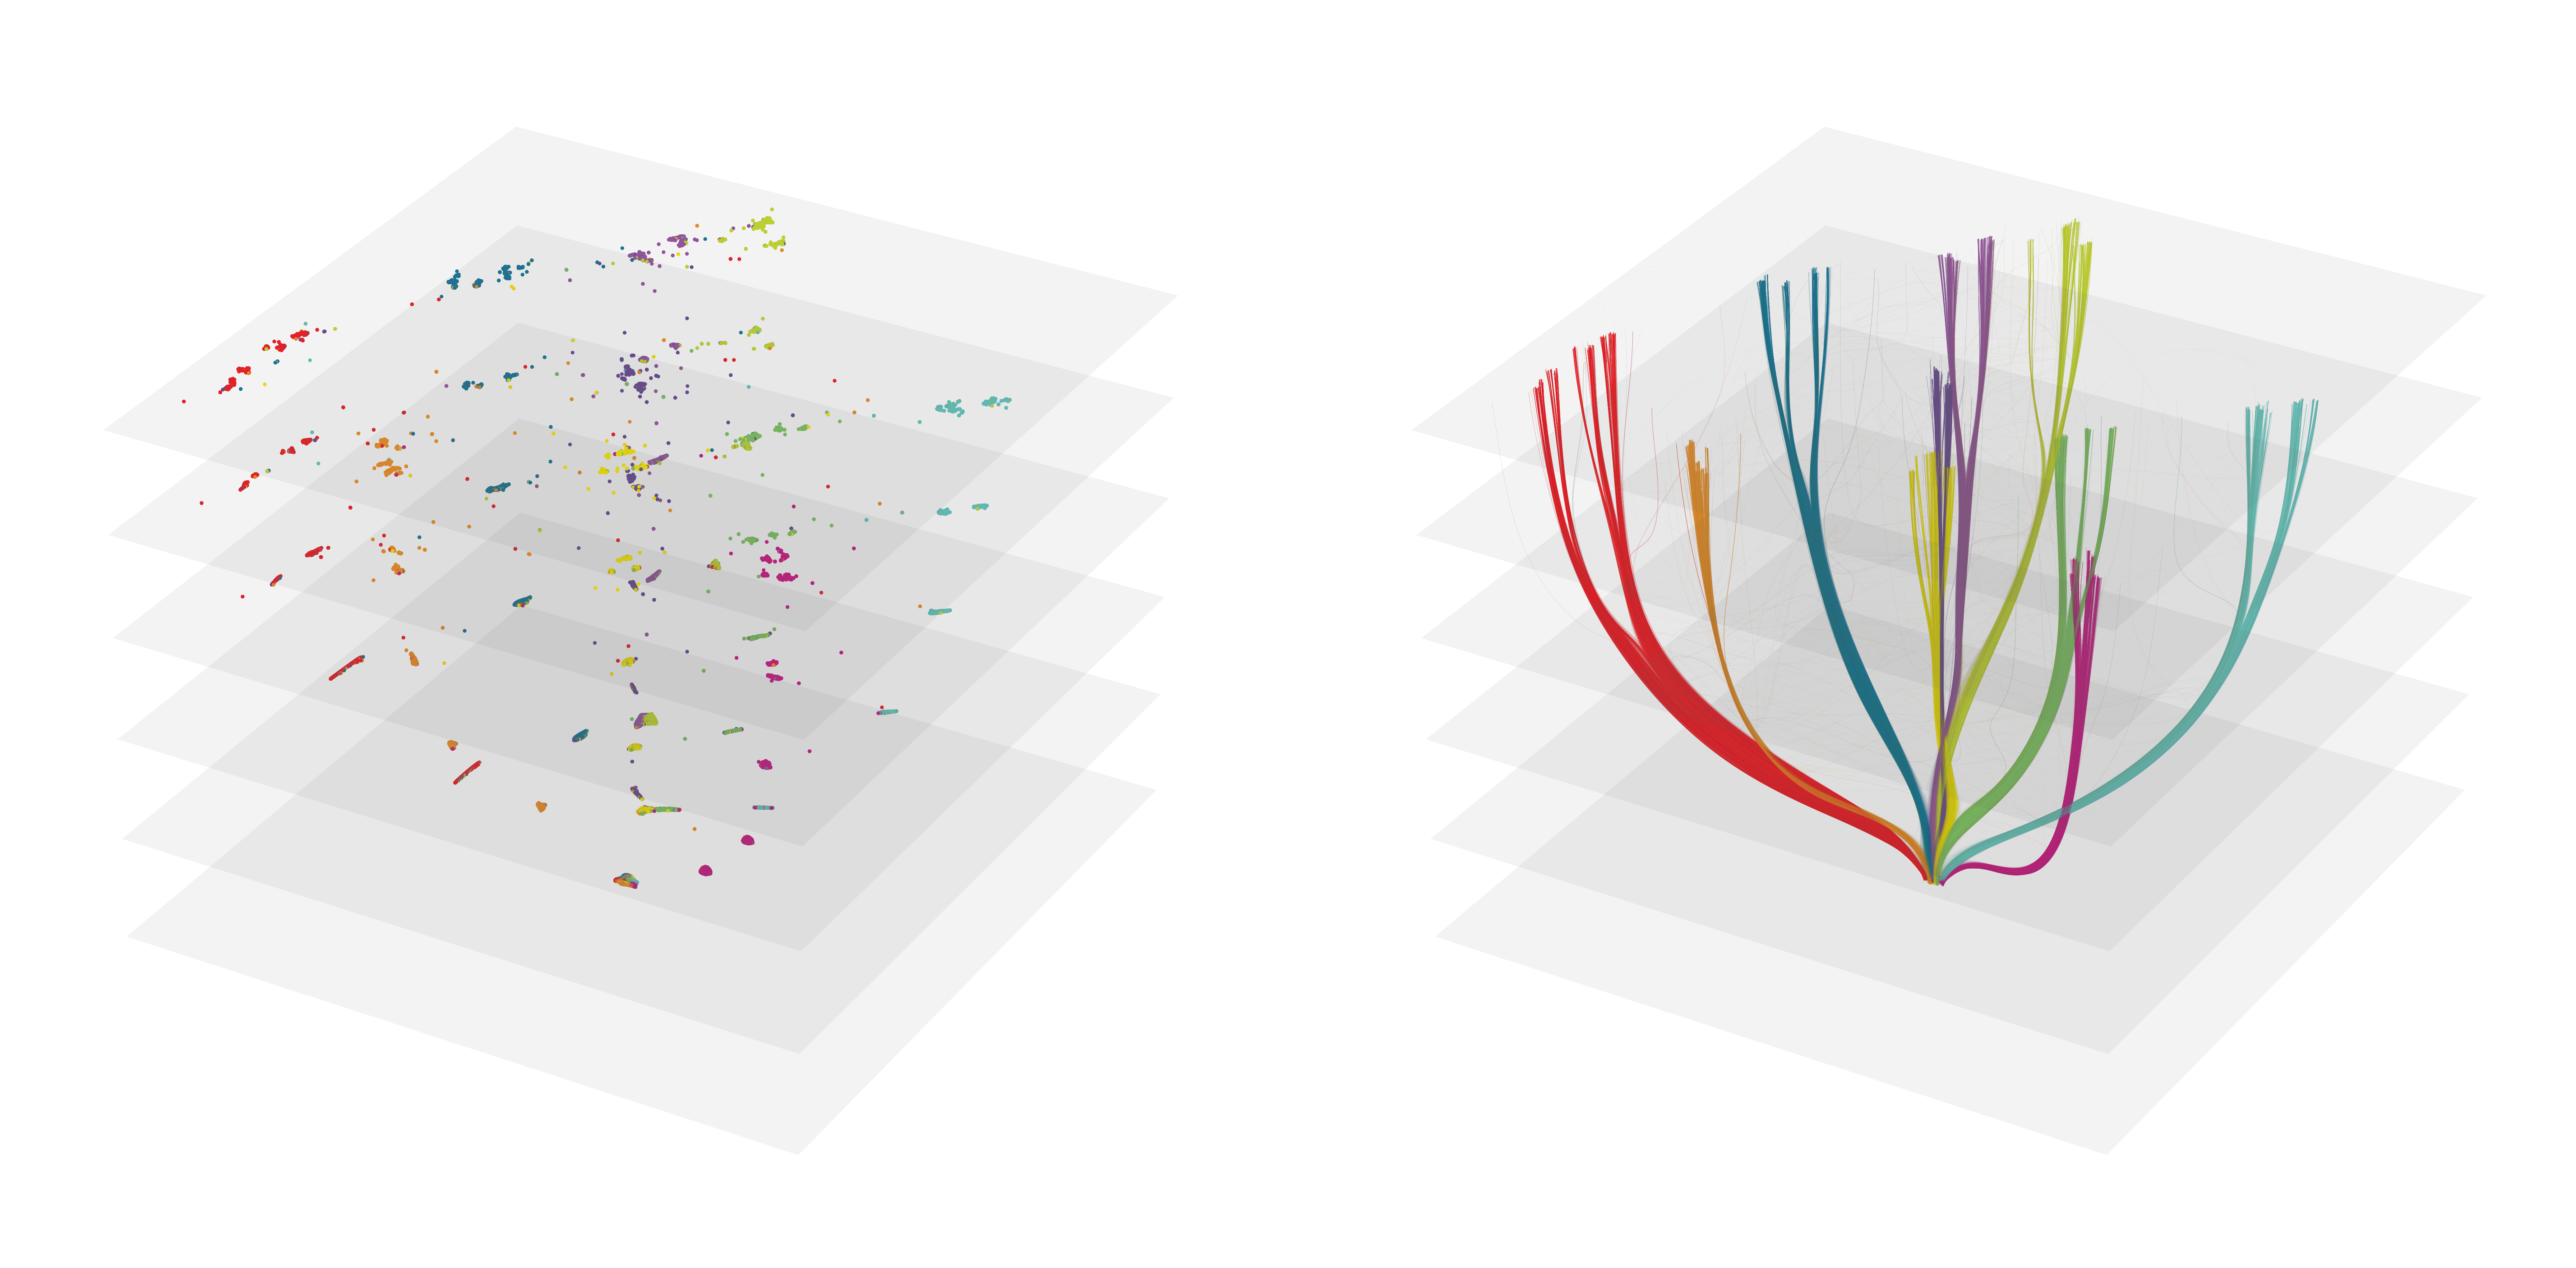

In [ ]:
fig = plt.figure(figsize=(24,12), dpi=300)
ax = fig.add_subplot(1, 2, 1, projection='3d')

zs = [0, 10, 20, 30, 40, 50]

for i in range(6):
    ax.scatter(xs = stack_fits[zs[i]][:, 0], 
            ys=stack_fits[zs[i]][:, 1],  
            zs=stack_fits[zs[i]][:, 2], 
            c=col[y], s=2, alpha=1)


xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(*xlim, 10), np.linspace(*ylim, 10))
zzs = [np.full_like(xx, i) for i in zs]

for i in range(6):
    ax.plot_surface(xx, yy, zzs[i], alpha=0.075, color='gray', linewidth=0, edgecolor='none')


ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_zlim(0, 50)
ax.axis('off')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(stack_fits.shape[1]):
    points = [stack_x[i], stack_y[i], stack_z[i]]
    tck, u = splprep(points, s=0.5)
    u_fine = np.linspace(0, 1, 500)
    x_smooth, y_smooth, t_smooth = splev(u_fine, tck)
    ax2.plot(x_smooth, y_smooth, t_smooth, alpha=0.1, color=col[y[i]], linewidth=0.1)

for i in range(6):
    ax2.plot_surface(xx, yy, zzs[i], alpha=0.075, color='gray', linewidth=0, edgecolor='none')


ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_zlim(0, 50)
ax2.axis('off')

#ax.legend()
plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
plt.show()

In [11]:
alphas = []

cl = {1: [3, 6, 30],
      2: [5, 14, 17],
     4: [2, 8, 37],
     7: [13, 20, 22]}


branches = [3, 6, 5, 17, 2, 8, 13, 20]

for i in range(70000):
    if labellings[5][i] in branches:
        alphas.append(0.1)
    else:
        alphas.append(0)

100%|██████████| 70000/70000 [00:25<00:00, 2705.96it/s]


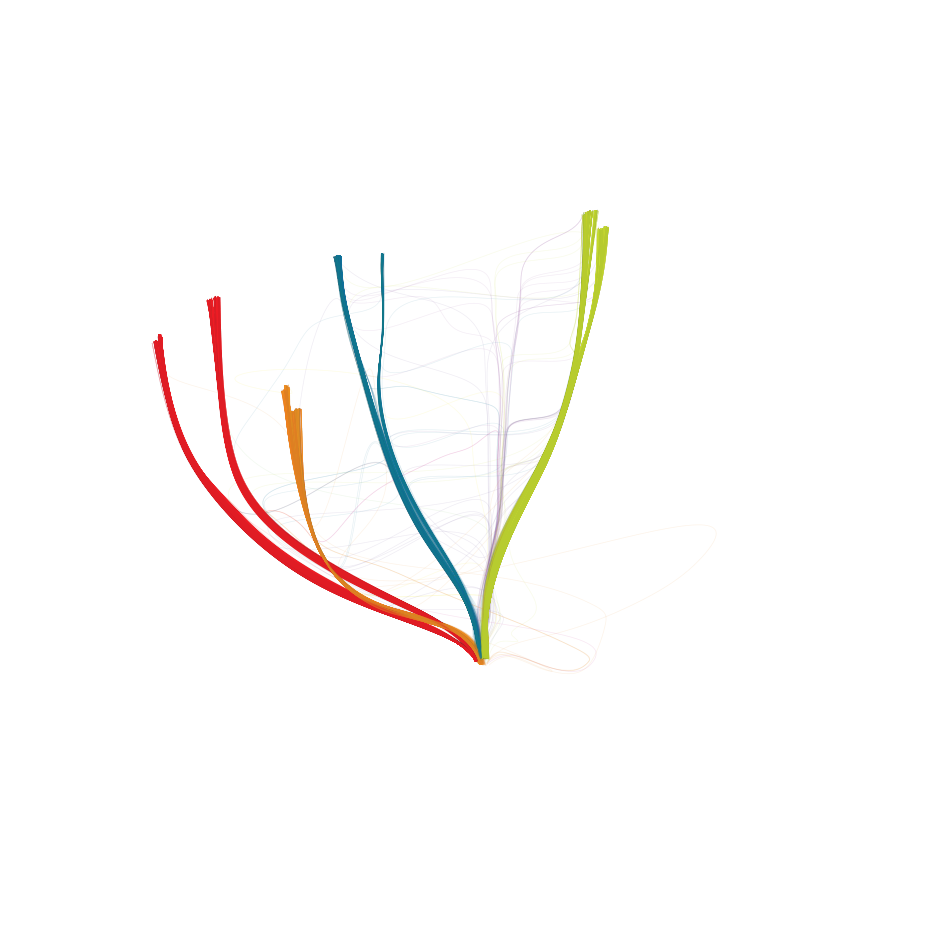

In [49]:
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(projection='3d')

# for i in range(51):
#     ax.scatter(xs = stack_fits[i][:, 0], 
#                 ys=stack_fits[i][:, 1],  
#                 zs=stack_fits[i][:, 2], 
#                 c=col[y], s=0.5, alpha=0.1)
    
for i in tqdm(range(stack_fits.shape[1])):
    if labellings[5][i] in [3, 6, 30, 5, 14, 17, 13, 20, 22, 2, 8, 37]:
# Fit a parametric spline to (x, y) over time
        points = [stack_x[i], stack_y[i], stack_z[i]]  # parametric curve in 3D

        tck, u = splprep(points, s=0.5)  # s is smoothing factor

        # Evaluate spline at finer resolution
        u_fine = np.linspace(0, 1, 500)
        x_smooth, y_smooth, t_smooth = splev(u_fine, tck)


        ax.plot(x_smooth, y_smooth, t_smooth, alpha=alphas[i], color=col[y[i]], linewidth=0.5)

ax.axis('off')
#ax.legend()
#ax.view_init(azim=15)
plt.show()